In [8]:
# ============================================
# Notebook 1: Images are Numbers
# Goal:
# Understand that images are just arrays of numbers.
# We will use NumPy (arrays), OpenCV (images), and Matplotlib (display).
# ============================================

# --- Imports ---
import numpy as np               # numerical arrays (core of everything)
import matplotlib.pyplot as plt  # display images
import cv2                       # computer vision library

numpy version: 1.26.4
opencv version: 4.10.0


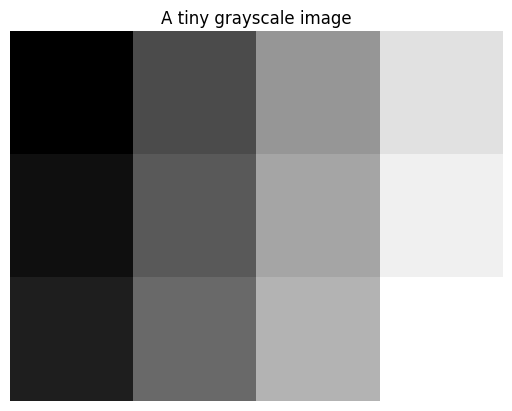

In [57]:
# ============================================
# 🧪 Example: A tiny grayscale image
# Goal:
# Understand how an image = a 2D array of numbers
# ============================================

# A tiny 3x4 "image" (grayscale = 1 channel)
# Each number = brightness of a pixel (0 = black, 255 = white)
img = np.array([
    [0,  50, 100, 150],
    [10, 60, 110, 160],
    [20, 70, 120, 170]
], dtype=np.uint8)  # uint8 = standard image format (0–255)

# --- Display the image ---
plt.imshow(img, cmap="gray")  # cmap="gray" = interpret values as grayscale
plt.title("A tiny grayscale image")
plt.axis("off")
plt.show()

In [3]:
# ============================================
# ✍️ Your turn (fill the gaps)
# ============================================

# 1. Print the value of the pixel at row 1, column 2
pixel_value = ???  
print("Pixel value:", pixel_value)

SyntaxError: invalid syntax (1495363942.py, line 6)

In [4]:
# 2. Change the top-left pixel to white (255)
img[0, 0] = ???

# 3. Display the updated image
plt.imshow(img, cmap="gray")
plt.title("Modified image")
plt.axis("off")
plt.show()

SyntaxError: invalid syntax (3906157078.py, line 2)

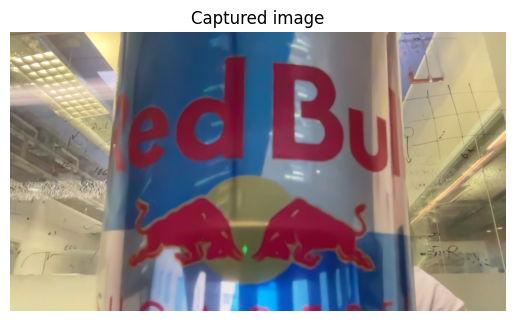

In [10]:
# ============================================
# 📷 Capture an image from your camera
# Goal:
# Take one picture using your computer camera
# and display it
# ============================================

# --- Open the default camera ---
cap = cv2.VideoCapture(0)

# Check that the camera opened correctly
if not cap.isOpened():
    print("Could not open camera.")
else:
    # --- Let the camera warm up ---
    for _ in range(20):
        ret, frame = cap.read()

    # Release the camera
    cap.release()

    # Check if capture worked
    if not ret:
        print("Failed to capture image.")
    else:
        # --- Save the image ---
        cv2.imwrite("../images/captured_image.png", frame)

        # Convert BGR → RGB for matplotlib
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Display the image
        plt.imshow(rgb)
        plt.title("Captured image")
        plt.axis("off")
        plt.show()

OpenCV loads images in BGR format (not RGB!)
shape (H, W, C): (1080, 1920, 3)
dtype: uint8


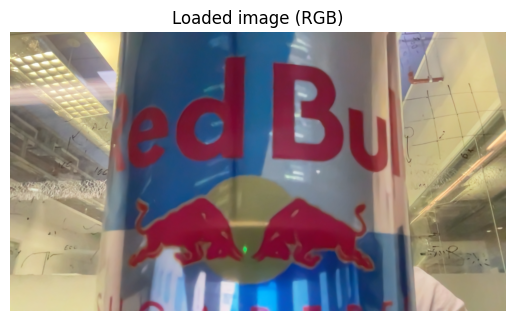

In [13]:
# ============================================
# 🖼️ Load a real image
# Goal:
# Understand how images are stored as 3D arrays (H, W, C)
# and why OpenCV uses BGR instead of RGB
# ============================================

# Path to your image (make sure the file exists)
path = "../images/captured_image.png"

# Load the image using OpenCV
bgr = cv2.imread(path)

# --- Safety check ---
if bgr is None:
    raise FileNotFoundError(
        f"Couldn't load {path}. Make sure the file exists."
    )

# --- Inspect the image ---
print("OpenCV loads images in BGR format (not RGB!)")
print("shape (H, W, C):", bgr.shape)  # Height, Width, Channels
print("dtype:", bgr.dtype)

# ============================================
# 🧠 Checkpoint:
# - How many channels does this image have?
# - What do you think each channel represents?
# ============================================


# --- Convert BGR → RGB (for correct display) ---
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(rgb)
plt.title("Loaded image (RGB)")
plt.axis("off")
plt.show()

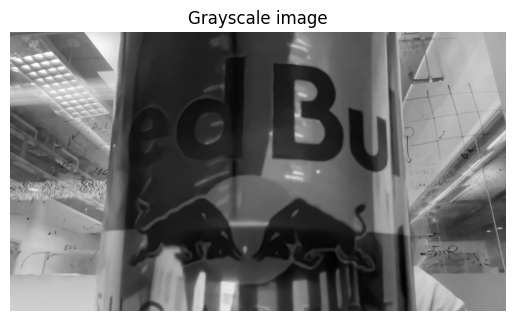

In [78]:
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale image")
plt.axis("off")
plt.show()

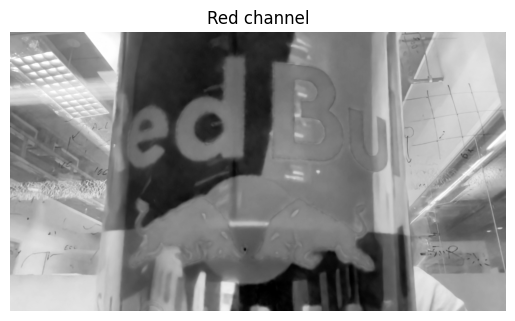

In [44]:
# ============================================
# 🖼️ Working with color channels
# Goal:
# Understand how to access individual RGB channels
# ============================================

# --- Example: Extract the RED channel ---
# In RGB: channel 0 = Red, 1 = Green, 2 = Blue
red_channel = rgb[:, :, 0]

plt.imshow(red_channel, cmap="gray")
plt.title("Red channel")
plt.axis("off")
plt.show()

In [45]:
# ============================================
# 🧠 Checkpoint:
# - What happens if a channel has high values?
# - What do you expect the blue channel to look like?
# ============================================


# ============================================
# ✍️ Your turn
# ============================================

# Extract the BLUE channel
blue_channel = ???

plt.imshow(blue_channel, cmap="gray")
plt.title("Blue channel")
plt.axis("off")
plt.show()

SyntaxError: invalid syntax (88564137.py, line 6)

Saved: ../pictures/captured_frame_red_filtered.png


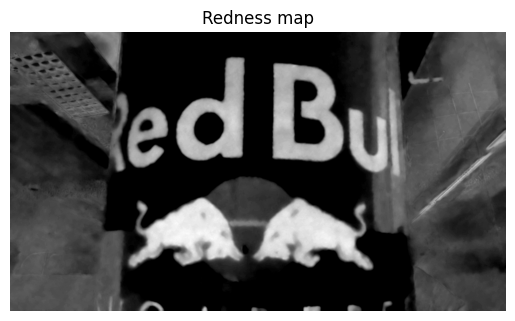

In [37]:
# ============================================
# 🔴 Redness map
# Goal:
# Highlight areas where red is dominant
# ============================================

# Extract color channels (convert to float for computation)
R = rgb[:, :, 0].astype(float)
G = rgb[:, :, 1].astype(float)
B = rgb[:, :, 2].astype(float)

# Compute "redness"
# High when red is stronger than green and blue
redness = R - 0.5 * (G + B)

# Keep values in valid range [0, 255]
redness = redness.clip(0, 255).astype("uint8")

# Save result
output_path = "../pictures/captured_frame_red_filtered.png"
cv2.imwrite(output_path, redness)

print("Saved:", output_path)

# Display result
plt.imshow(redness, cmap="gray")
plt.title("Redness map")
plt.axis("off")
plt.show()


# ============================================
# 🧠 Checkpoint:
# - What kind of areas appear bright?
# - What happens if there is little red?
# ============================================

In [46]:
# ============================================
# Goal:
# Highlight areas where blue is dominant
# ============================================

# Extract color channels (convert to float for computation)
R = rgb[:, :, 0].astype(float)
G = rgb[:, :, 1].astype(float)
B = rgb[:, :, 2].astype(float)

# Compute "redness"
# High when red is stronger than green and blue
redness = ???

# Keep values in valid range [0, 255]
blueness = redness.clip(0, 255).astype("uint8")

# Save result
output_path = "../pictures/captured_frame_blue_filtered.png"
cv2.imwrite(output_path, blueness)

print("Saved:", output_path)

# Display result
plt.imshow(redness, cmap="gray")
plt.title("Redness map")
plt.axis("off")
plt.show()


# ============================================
# 🧠 Checkpoint:
# - What kind of areas appear bright?
# - What happens if there is little red?
# ============================================

SyntaxError: invalid syntax (696266133.py, line 14)

In [ ]:
# REd channel with video

In [ ]:
import cv2
import time

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            R = frame[:, :, 2]

            cv2.imshow("Red Channel", R)

            # Stop after 20 seconds
            if time.time() - start_time > 20:
                break

            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

    finally:
        cap.release()

        # 🔴 CRITICAL: give OpenCV time to process window close
        cv2.waitKey(1)
        cv2.destroyAllWindows()
        cv2.waitKey(1)

In [ ]:
# Redness map with video

In [8]:
import cv2
import numpy as np
import time

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            # Convert BGR → RGB
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # --- Compute redness map ---
            R = rgb[:, :, 0].astype(float)
            G = rgb[:, :, 1].astype(float)
            B = rgb[:, :, 2].astype(float)

            redness = R - 0.5 * (G + B)
            redness = redness.clip(0, 255).astype("uint8")

            # --- Display in separate window ---
            # cv2.imshow("Live Redness Map", redness)

            # Stop after 20 seconds
            if time.time() - start_time > 3:
                break

            # Optional: press q to quit early
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

    finally:
        cap.release()
        cv2.waitKey(1)
        cv2.destroyAllWindows()
        cv2.waitKey(1)

In [ ]:
# redness map with False colors

In [16]:
import cv2
import numpy as np
import time

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            # Convert BGR → RGB
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # --- Compute redness map ---
            R = rgb[:, :, 0].astype(float)
            G = rgb[:, :, 1].astype(float)
            B = rgb[:, :, 2].astype(float)

            redness = R - 0.5 * (G + B)
            redness = redness.clip(0, 255).astype("uint8")

            # --- Display in separate window ---
            # cv2.imshow("Live Redness Map", cv2.applyColorMap(redness, cv2.COLORMAP_JET))
            cv2.imshow("Live Redness Map", cv2.applyColorMap(redness, cv2.COLORMAP_HOT))
            # cv2.imshow("Live Redness Map", cv2.applyColorMap(redness, cv2.COLORMAP_TURBO))
            # cv2.imshow("Live Redness Map", cv2.applyColorMap(redness, cv2.COLORMAP_VIRIDIS))

            # Stop after 20 seconds
            if time.time() - start_time > 3:
                break

            # Optional: press q to quit early
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

    finally:
        cap.release()
        cv2.waitKey(1)
        cv2.destroyAllWindows()
        cv2.waitKey(1)

In [ ]:
# What's you favorite colormap? 
